# Fourier vs Wavelet Approximation

We compare linear Fourier truncation and nonlinear Haar thresholding.


In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from IPython import get_ipython

ip = get_ipython()
if ip is not None:
    ip.run_line_magic("matplotlib", "inline")

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True
rng = np.random.default_rng(0)
OUT = Path(".")

import ipywidgets as widgets
n = 512
t = np.linspace(0, 1, n, endpoint=False)
f = np.sin(2*np.pi*3*t) + 0.7*(t>0.37) - 0.5*(t>0.73) + 0.2*rng.normal(size=n)

def fourier_linear(rate):
    m = max(1, int(rate*n/2))
    F = np.fft.rfft(f)
    keep = np.zeros_like(F, dtype=bool); keep[:m] = True
    return np.fft.irfft(F*keep, n=n)

def haar_nonlin(rate):
    a = f.copy()
    coeffs = []
    L = n
    while L > 1:
        even = a[:L:2]; odd = a[1:L:2]
        avg = (even+odd)/2
        det = (even-odd)/2
        coeffs.append(det)
        a[:L//2] = avg
        L //= 2
    det_all = np.concatenate([c.ravel() for c in coeffs])
    k = max(1, int(rate*len(det_all)))
    th = np.partition(np.abs(det_all), -k)[-k]
    # reconstruct by thresholding details levelwise
    a = f.copy(); stack=[]
    L = n
    while L > 1:
        even = a[:L:2]; odd = a[1:L:2]
        avg = (even+odd)/2
        det = (even-odd)/2
        det[np.abs(det) < th] = 0
        stack.append((avg.copy(), det.copy()))
        a[:L//2] = avg
        L //= 2
    val = stack[-1][0]
    for avg, det in stack[::-1]:
        out = np.empty(avg.size*2)
        out[0::2] = avg + det
        out[1::2] = avg - det
        avg = out
    return avg


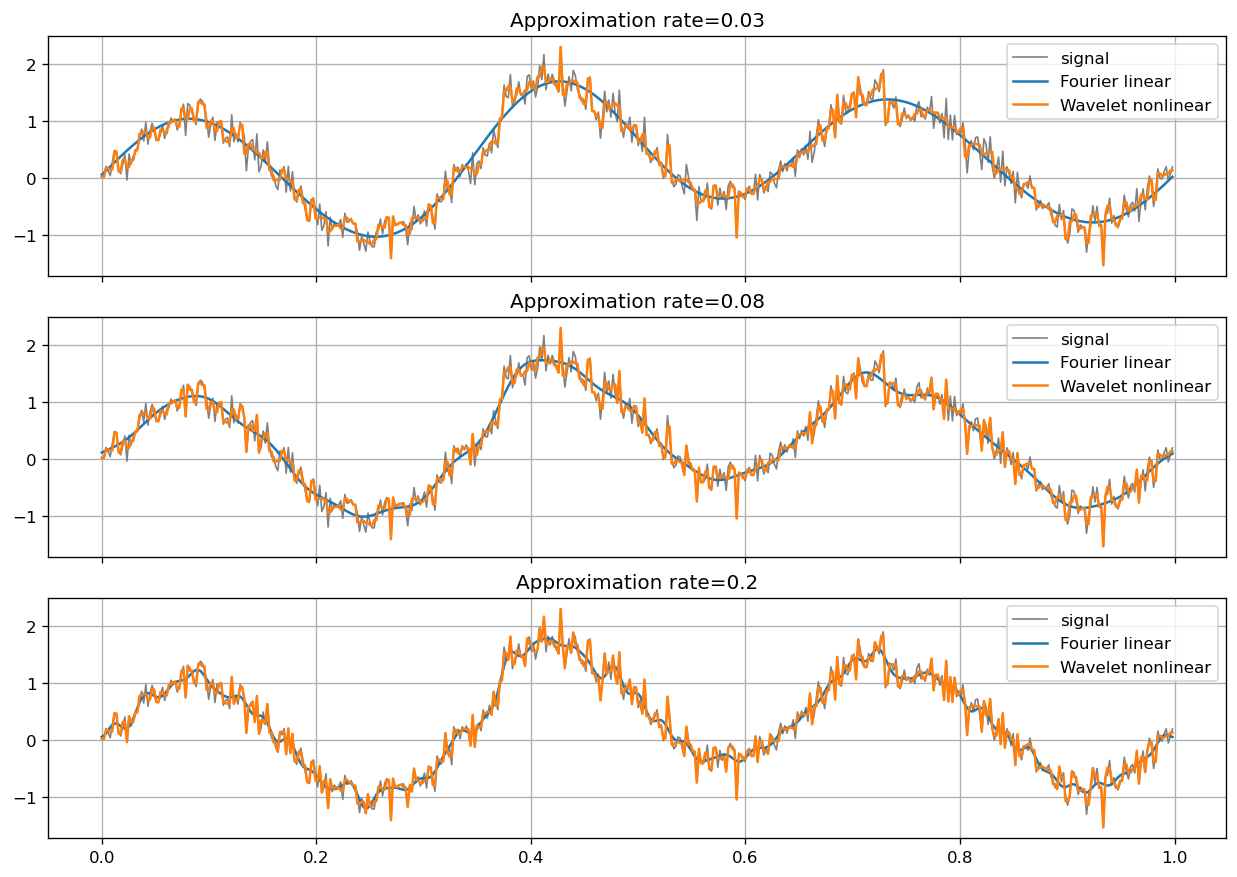

In [2]:
rates = [0.03, 0.08, 0.2]
fig, axes = plt.subplots(3, 1, figsize=(10.2, 7.2), sharex=True, constrained_layout=True)
for ax, r in zip(axes, rates):
    ax.plot(t, f, color='0.5', lw=1.0, label='signal')
    ax.plot(t, fourier_linear(r), lw=1.5, label='Fourier linear')
    ax.plot(t, haar_nonlin(r), lw=1.5, label='Wavelet nonlinear')
    ax.set_title(f'Approximation rate={r}')
    ax.legend()
fig.savefig(OUT / "snippet.png", bbox_inches="tight")
plt.show()


## Interactive slider
